# NanoGPT

In [25]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import os

In [26]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 20,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 16,
    "axes.linewidth": 1.4,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linestyle": "--",
    "grid.linewidth": 0.9,
    "lines.linewidth": 3.5,
    "lines.markersize": 11,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.major.width": 1.3,
    "ytick.major.width": 1.3,
    "legend.frameon": True,
    "legend.framealpha": 0.95,
    "legend.edgecolor": "0.75",
    "legend.fancybox": False,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
          "#915cc2", "#37200E", "#10C5D5", "#4A3322", "#bcbd22", "#17becf"]

_METRIC_NAMES = {
    "val_loss": "Validation loss",
    "train_loss": "Train loss",
}

In [27]:
def load_run(run_dir):
    with open(Path(run_dir) / "metrics.json", "r") as f:
        return json.load(f)


def existing_runs(run_dirs, labels):
    rd_out, lb_out = [], []
    for rd, lb in zip(run_dirs, labels):
        if (Path(rd) / "metrics.json").exists():
            rd_out.append(rd)
            lb_out.append(lb)
        else:
            print(f"[skip] нет {rd}/metrics.json")
    return rd_out, lb_out


def plot_nano(run_dirs, labels, xkey="step", ykey="val_loss",
              xlabel=None, ylabel=None, figsize=(10, 6.5),
              x_divisor=1.0, xscale=None, xlim=None, ylim=None,
              save_path=None):
    fig, ax = plt.subplots(figsize=figsize)
    for i, (run_dir, label) in enumerate(zip(run_dirs, labels)):
        history = load_run(run_dir)["history"]
        y = np.asarray(history[ykey], dtype=float)
        x = (np.arange(1, len(y) + 1) if xkey is None
             else np.asarray(history[xkey], dtype=float) / x_divisor)
        ax.plot(x, y, label=label, color=COLORS[i % len(COLORS)],
                linewidth=3.5, alpha=0.85, solid_capstyle="round", zorder=3)

    ax.set_xlabel(xlabel if xlabel else (xkey if xkey else "index"), fontsize=20)
    ax.set_ylabel(ylabel if ylabel else _METRIC_NAMES.get(ykey, ykey), fontsize=20)
    if xscale:
        ax.set_xscale(xscale)
    if xlim:
        ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    ax.tick_params(axis="both", labelsize=16, length=6, width=1.3)
    ax.grid(True, linestyle="--", linewidth=0.9, alpha=0.25, zorder=0)
    ax.legend(loc="best", fontsize=16, frameon=True, framealpha=0.95, edgecolor="0.75")
    fig.tight_layout()
    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


def print_final_metrics(run_dirs, labels):
    for run_dir, label in zip(run_dirs, labels):
        data = load_run(run_dir)
        h, cfg = data["history"], data.get("config", {})
        if not h["step"]:
            print(f"{label:<16} (пустая history)")
            continue
        final_step = h["step"][-1]
        final_val = h["val_loss"][-1]
        total_comm_gb = h["comm_bytes"][-1] / 1e9
        bits = cfg.get("comm_bits_per_param", "?")
        print(f"{label:<16} step={final_step:>5}  val_loss={final_val:.4f}  "
              f"comm={total_comm_gb:9.2f} GB  ({bits} bits/param/step)")

In [28]:
print(os.getcwd())

/home/stsix/project


In [29]:
SAVES_DIR = Path("saves_nano")

RUNS = [
    ("muon",          "Muon"),
    ("signmuon",      "SignMuon"),
    ("muonsign",      "MuonSign"),
    ("ef_usignmuon",  "EF-USignMuon"),
    ("ef_udsignmuon", "EF-UDSignMuon"),
    ("signsgd",       "SignSGD"),
]

run_dirs = [SAVES_DIR / name for name, _ in RUNS]
labels   = [lab for _, lab in RUNS]

run_dirs, labels = existing_runs(run_dirs, labels)
print("активных:", len(run_dirs))

[skip] нет saves_nano/muon/metrics.json
[skip] нет saves_nano/muonsign/metrics.json
[skip] нет saves_nano/ef_usignmuon/metrics.json
[skip] нет saves_nano/ef_udsignmuon/metrics.json
[skip] нет saves_nano/signsgd/metrics.json
активных: 1


In [30]:
print_final_metrics(run_dirs, labels)

SignMuon         step= 2000  val_loss=7.4615  comm=   681.25 GB  (33 bits/param/step)


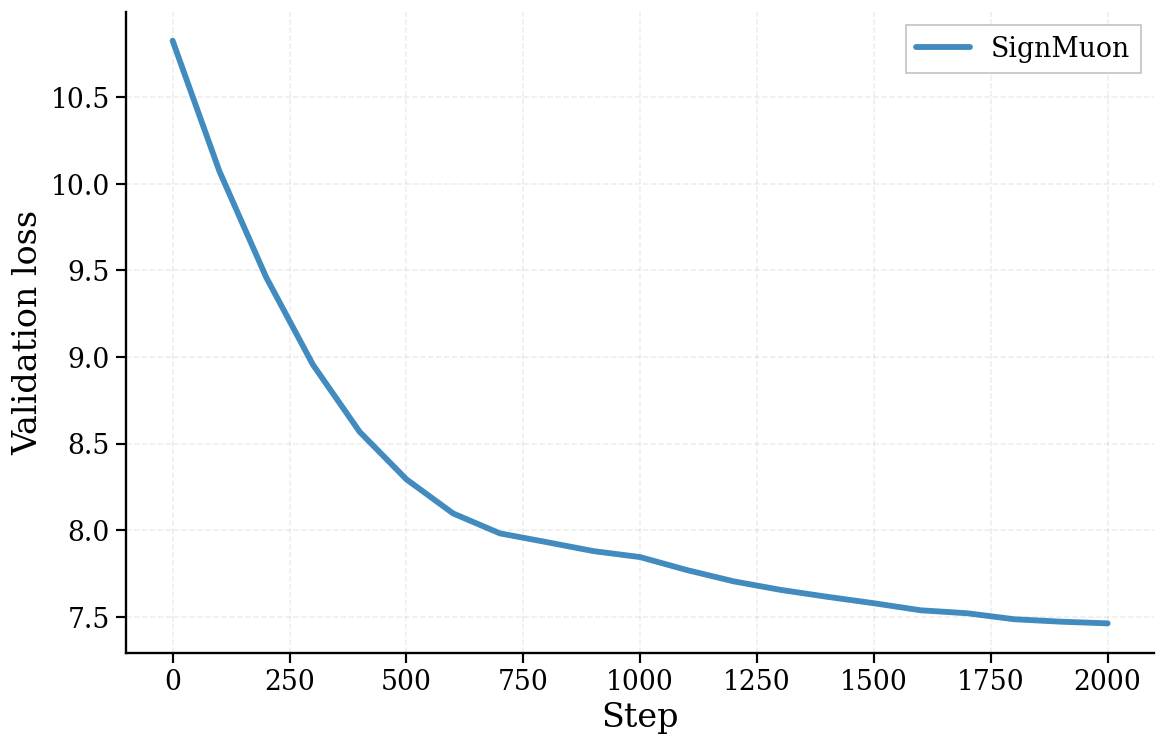

In [31]:
plot_nano(run_dirs, labels,
          xkey="step", ykey="val_loss",
          xlabel="Step", ylabel="Validation loss",
          save_path="im_nano/val_loss_vs_step.pdf")

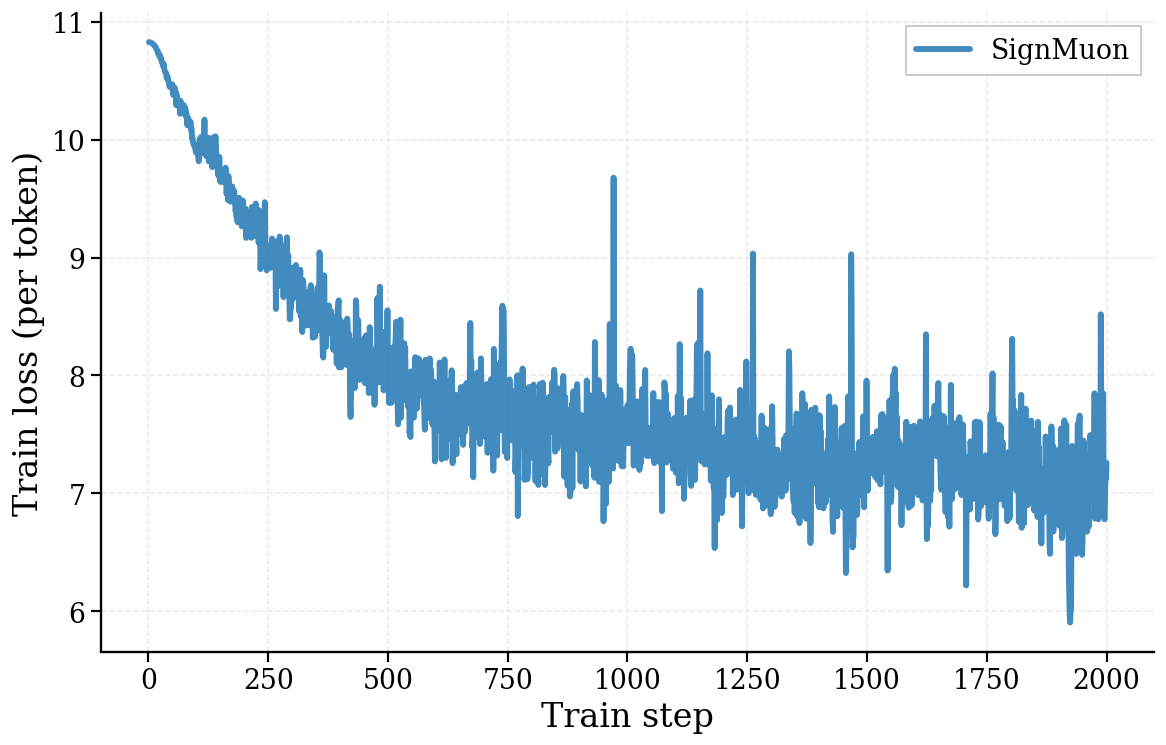

In [32]:
plot_nano(run_dirs, labels,
          xkey=None, ykey="train_loss",
          xlabel="Train step", ylabel="Train loss (per token)",
          save_path="im_nano/train_loss_vs_step.pdf")